In [8]:
%run 00_config.py

In [9]:
import json
data = []
with open('product-train.jsonl') as f:
    for line in f:
        data.append(json.loads(line))

In [10]:
print (f"found {len(data)} total products")

found 10002 total products


##### here we tally up some stats

- How many valid images were downloaded
- The total number of transparent-pixel images (it's always last in the images array)
- Number of images with a bad URL (ie. not downloaded)
- Total number of products that have **some** missing images
- Total number of products that have no valid images


In [11]:
import os
products_0images = []
products_all_images = []
products_missing_images_count = 0
not_downloaded_image_count = 0
downloaded_image_count = 0
transparent_pixel_count = 0
for i in data:
    product_id = i['Uniq Id']

    all_images_urls = list(enumerate(i.get('Image', '').split('|'))) # all image URLs https://... 
    image_file_paths = list(map(lambda x, id=product_id: local_img_path(x, id), all_images_urls)) # all local image paths product_images/...
    if len(all_images_urls) > 0:
        if "transparent-pixel" in image_file_paths[-1].lower():
            image_file_paths = image_file_paths[:-1]        # remove transparent pixel image and always, it is the last image
            transparent_pixel_count += 1
        valid_images_bool = [1 if os.path.isfile(img_path) else 0 for img_path in image_file_paths]
        downloaded_image_count += sum(valid_images_bool) # count of valid images that are downloaded
        not_downloaded_image_count += valid_images_bool.count(0)
        products_missing_images_count += 1 if not all(valid_images_bool) else 0
        for j in image_file_paths:
            if not os.path.isfile(j):
                #print(f"Image file {j} does not exist")
                pass
        if not any(valid_images_bool):
            #print(f"All images are invalid for product id: {i['Uniq Id']}, name: {i['Product Name']}")
            products_0images.append( (product_id, i['Product Name']) )
        if all(valid_images_bool):
            products_all_images.append( (i['Uniq Id'], i['Product Name']) )
print()
print(f"Total image URLs: {downloaded_image_count + not_downloaded_image_count + transparent_pixel_count}, \
Downloaded: {downloaded_image_count } images, not downloaded: {not_downloaded_image_count} images, \
and {transparent_pixel_count} transparent pixel images")

print(f"There are {len(products_0images)} products with 0 available images, {len(products_all_images)} products with no missing images, \
{products_missing_images_count} products with some missing images")




Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename enjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename enjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename enjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename STANDARDjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error splitting filename HOUSEjpg: not enough values to unpack (expected 2, got 1)
Error spli

##### Some analysis for building full text index to concatenate: Product Name, About Product, Details, and Category

In [12]:
namenull = 0
brandnull = 0
aboutnull = 0
proddetailsnull = 0
categorynull = 0
for product in data:
    if (product.get('Product Name')) is None:
        namenull += 1
    if (product.get('Brand Name')) is None:
        brandnull += 1
    if (product.get('About Product')) is None:
        aboutnull += 1
    if (product.get('Product Details')) is None:
        proddetailsnull += 1
    if (product.get('Category')) is None:
        categorynull += 1
print(f"Number of products with null 'Product Name': {namenull}")
print(f"Number of products with null 'Brand name': {brandnull}")
print(f"Number of products with null 'About Product': {aboutnull}")
print(f"Number of products with null 'Product Details': {proddetailsnull}")
print(f"Number of products with null 'Category': {categorynull}")

Number of products with null 'Product Name': 0
Number of products with null 'Brand name': 10002
Number of products with null 'About Product': 273
Number of products with null 'Product Details': 10002
Number of products with null 'Category': 830


In [13]:
max_length = 0
histogram_data = []
for product in data:
    comprehensive_description_array = []
    if (product.get('Product Name')) is not None:
        comprehensive_description_array.append(product.get('Product Name', ''))
    if (product.get('Category')) is not None:
        comprehensive_description_array.append(" categorized within " + ",".join(product.get('Category', '').split(' | ')))
    if (product.get('About Product')) is not None:
        comprehensive_description_array.append("with details - " + product.get('About Product', ''))
    comprehensive_description = ' '.join(comprehensive_description_array)
    if(len(comprehensive_description) > max_length):
        max_length = len(comprehensive_description)
        unique_id = product.get('Uniq Id', 'Unknown')
    total_length = len(comprehensive_description)
    histogram_data.append(total_length)
print(f"max length: {max_length} for product {unique_id}")
print(f"comprehensive_description: {comprehensive_description}")


max length: 2816 for product 60171d5a7f1e4ee5e27786519f5107b8
comprehensive_description: Hasegawa Ladders Lucano Step Ladder, Orange  categorized within Home & Kitchen,Furniture,Kids' Furniture,Step Stools with details - Make sure this fits by entering your model number. | 90% Aluminum, 10% Resin | Design by chiaki Murata of World famous Studio metaphys | Stands on it's own when folded | Steps with integrated grooves for a firm grip | Sturdy, safe ladder, holding up till 225 lbs. weight | Material: 90% Powder coated Aluminum, 10% Resin


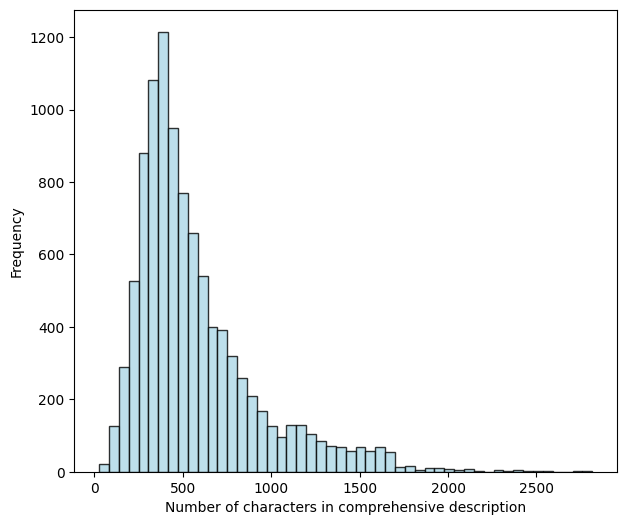

In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7, 6))
plt.hist(histogram_data, bins=50, color='lightblue', alpha=0.8, edgecolor='black')
plt.xlabel('Number of characters in comprehensive description')
plt.ylabel('Frequency')
plt.show()

In [15]:
max_length = 0
histogram_data = []
for product in data:
    comprehensive_description_array = []
    if (product.get('Product Name')) is not None:
        comprehensive_description_array.append(product.get('Product Name', ''))
    comprehensive_description = ' '.join(comprehensive_description_array)
    if(len(comprehensive_description) > max_length):
        max_length = len(comprehensive_description)
        unique_id = product.get('Uniq Id', 'Unknown')
    total_length = len(comprehensive_description)
    histogram_data.append(total_length)
print(f"max length: {max_length} for product {unique_id}")
print(f"comprehensive_description: {comprehensive_description[:300]}...")


max length: 200 for product c15e7efbe14b9bbcb8b7fe31f9818021
comprehensive_description: Hasegawa Ladders Lucano Step Ladder, Orange...


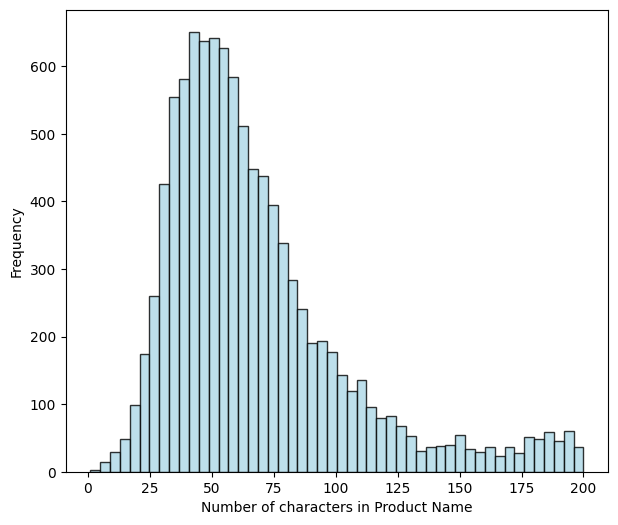

In [16]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7, 6))
plt.hist(histogram_data, bins=50, color='lightblue', alpha=0.8, edgecolor='black')
plt.xlabel('Number of characters in Product Name')
plt.ylabel('Frequency')
plt.show()